In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
url = 'https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv'
df = pd.read_csv(url)

In [3]:
df.head()

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,Europe,Gasoline,Front-wheel drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,USA,Diesel,Front-wheel drive,3,2580,7,304.0,4510,17.5,31.0


In [4]:
df.shape

(10000, 11)

In [5]:
df = df[[
    'engine_displacement',
    'horsepower',
    'vehicle_weight',
    'model_year',
    'fuel_efficiency_mpg'
]]
df.head()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2180,243.0,3870,2006,31.9
1,2390,272.0,4210,2008,31.3
2,2320,267.0,4240,1996,27.5
3,2130,258.0,4490,1989,28.5
4,2580,304.0,4510,1994,31.0


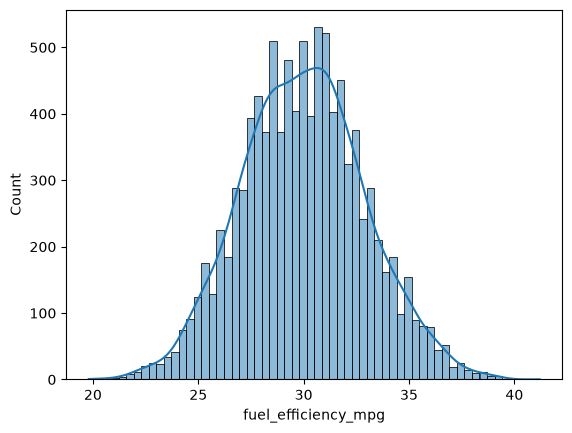

In [6]:
sns.histplot(df['fuel_efficiency_mpg'], kde=True)
plt.show()

In [7]:
df.isnull().sum()

engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

In [8]:
df['horsepower'].median()

np.float64(254.0)

In [9]:
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

In [10]:
n, n_train, n_val, n_test

(10000, 6000, 2000, 2000)

In [11]:
np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]].reset_index(drop=True)
df_val   = df.iloc[idx[n_train:n_train + n_val]].reset_index(drop=True)
df_test  = df.iloc[idx[n_train + n_val:]].reset_index(drop=True)

In [12]:
y_train = df_train['fuel_efficiency_mpg'].values
y_val   = df_val['fuel_efficiency_mpg'].values
y_test  = df_test['fuel_efficiency_mpg'].values

del df_train['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']

In [13]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])
    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w = XTX_inv.dot(X.T).dot(y)
    return w[0], w[1:]

In [14]:
def rmse(y, y_pred):
    return np.sqrt(((y_pred - y) ** 2).mean())

In [15]:
X_train = df_train.fillna(0).values
X_val   = df_val.fillna(0).values

w0, w = train_linear_regression(X_train, y_train)
y_pred = w0 + X_val.dot(w)
print(round(rmse(y_val, y_pred), 3))

2.205


In [16]:
mean_hp = df_train['horsepower'].mean()
mean_hp

np.float64(254.46338337605272)

In [17]:
X_train = df_train.fillna(mean_hp).values
X_val   = df_val.fillna(mean_hp).values

w0, w = train_linear_regression(X_train, y_train)
y_pred = w0 + X_val.dot(w)
print(round(rmse(y_val, y_pred), 3))

2.202


In [18]:
def train_linear_regression_reg(X, y, r):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])
    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])
    XTX_inv = np.linalg.inv(XTX)
    w = XTX_inv.dot(X.T).dot(y)
    return w[0], w[1:]

In [19]:
X_train = df_train.fillna(0).values
X_val   = df_val.fillna(0).values

In [20]:
for r in [0, 0.01, 0.1, 1, 5, 10, 100]:
    w0, w = train_linear_regression_reg(X_train, y_train, r=r)
    y_pred = w0 + X_val.dot(w)
    print(r, round(rmse(y_val, y_pred), 4))

0 2.2053
0.01 2.2058
0.1 2.2241
1 2.3492
5 2.4094
10 2.4195
100 2.4292


In [21]:
def rmse_for_seed(seed):
    np.random.seed(seed)
    idx = np.arange(n)
    np.random.shuffle(idx)

    df_tr = df.iloc[idx[:n_train]].reset_index(drop=True)
    df_v  = df.iloc[idx[n_train:n_train + n_val]].reset_index(drop=True)

    y_tr = df_tr['fuel_efficiency_mpg'].values
    y_v  = df_v['fuel_efficiency_mpg'].values

    del df_tr['fuel_efficiency_mpg']
    del df_v['fuel_efficiency_mpg']

    X_tr = df_tr.fillna(0).values
    X_v  = df_v.fillna(0).values

    w0, w = train_linear_regression(X_tr, y_tr)
    y_pred = w0 + X_v.dot(w)
    return rmse(y_v, y_pred)

In [22]:
scores = []
for s in range(10):
    sc = rmse_for_seed(s)
    scores.append(sc)
    print(s, round(sc, 3))

0 2.239
1 2.202
2 2.163
3 2.204
4 2.202
5 2.246
6 2.27
7 2.191
8 2.217
9 2.207


In [23]:
np.std(scores)

np.float64(0.028781274078191175)

In [24]:
round(np.std(scores), 3)

np.float64(0.029)

In [25]:
np.random.seed(9)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]].reset_index(drop=True)
df_val   = df.iloc[idx[n_train:n_train + n_val]].reset_index(drop=True)
df_test  = df.iloc[idx[n_train + n_val:]].reset_index(drop=True)

y_train = df_train['fuel_efficiency_mpg'].values
y_val   = df_val['fuel_efficiency_mpg'].values
y_test  = df_test['fuel_efficiency_mpg'].values

df_full_train = pd.concat([df_train, df_val]).reset_index(drop=True)
y_full_train = np.concatenate([y_train, y_val])

del df_full_train['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']

In [26]:
X_full_train = df_full_train.fillna(0).values
X_test       = df_test.fillna(0).values

w0, w = train_linear_regression_reg(X_full_train, y_full_train, r=0.001)
y_pred = w0 + X_test.dot(w)
print(round(rmse(y_test, y_pred), 3))

2.236
